<a href="https://colab.research.google.com/github/MohamedAdel-Ibrahim/ECE570-Final-Project/blob/main/copy_of_123bestof_fnther_copy_of_project_2__1___1__working__1_4_2_ipynbbbb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/
!find /content/drive -name "*.zip"
!cp "/content/drive/MyDrive/ai_distracted2.zip" /content/
!ls /content/
!unzip "/content/ai_distracted2.zip" -d /content/
!ls /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/__MACOSX/ai_distracted2/train/c4/._757.jpg  
  inflating: /content/ai_distracted2/train/c4/756.jpg  
  inflating: /content/__MACOSX/ai_distracted2/train/c4/._756.jpg  
  inflating: /content/ai_distracted2/train/c4/971.jpg  
  inflating: /content/__MACOSX/ai_distracted2/train/c4/._971.jpg  
  inflating: /content/ai_distracted2/train/c4/1229.jpg  
  inflating: /content/__MACOSX/ai_distracted2/train/c4/._1229.jpg  
  inflating: /content/ai_distracted2/train/c4/965.jpg  
  inflating: /content/__MACOSX/ai_distracted2/train/c4/._965.jpg  
  inflating: /content/ai_distracted2/train/c4/1201.jpg  
  inflating: /content/__MACOSX/ai_distracted2/train/c4/._1201.jpg  
  inflating: /content/ai_distracted2/train/c4/795.jpg  
  inflating: /content/__MACOSX/ai_distracted2/train/c4/._795.jpg  
  inflating: /content/ai_distracted2/train/c4/781.jpg  
  inflating: /content/__MACOSX/ai_distracted2/train/c4/._781.jpg  
  inflating: /con

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.5 MB/s eta 0:00:00


In [ ]:
import os
import shutil

BASE_PATH = "/content/ai_distracted2"
CLASSES_TO_REMOVE = ["c6","c7","c8"]

SUBSETS = ["train" , "test"]

for subset in SUBSETS:
    subset_path = os.path.join(BASE_PATH , subset)
    print(f"[INFO] Cleaning subset directory: {subset_path}")

    for cls in CLASSES_TO_REMOVE:
        cls_path = os.path.join(subset_path, cls)

        if os.path.exists(cls_path):
            shutil.rmtree(cls_path)
            print(f"[INFO] Deleted class: {cls_path}")
        else:
            print(f"[WARNING] Path not found (skipping): {cls_path}")

print("[INFO] Target classes successfully purged from dataset.")


[INFO] Cleaning subset directory: /content/ai_distracted2/train
[INFO] Deleted class: /content/ai_distracted2/train/c6
[INFO] Deleted class: /content/ai_distracted2/train/c7
[INFO] Deleted class: /content/ai_distracted2/train/c8
[INFO] Cleaning subset directory: /content/ai_distracted2/test
[INFO] Deleted class: /content/ai_distracted2/test/c6
[INFO] Deleted class: /content/ai_distracted2/test/c7
[INFO] Deleted class: /content/ai_distracted2/test/c8
[INFO] Target classes successfully purged from dataset.


In [ ]:
import os
import cv2
import glob
import numpy as np
from tqdm import tqdm
RAW_ROOT = "/content/ai_distracted2"
ENH_ROOT = "/content/ai_distracted_enhanced2"

os.makedirs(ENH_ROOT, exist_ok=True)

def adjust_gamma(image , gamma=1.0):
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)


"""
    Applies a 3-stage illumination recovery pipeline (Median Blur, Gamma Correction, CLAHE)
    to resolve severe cabin shadowing and sensor noise.
    """
def apply_night_enhancement(img):

    denoised = cv2.medianBlur(img, 3)
    # gamma 1.5 selected as the optimal hyperparameter during phase 1 testing.
    gamma_corrected = adjust_gamma(denoised, gamma=1.5)
    lab = cv2.cvtColor(gamma_corrected, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)
    lab = cv2.merge((l,a,b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def enhance_split(split):
    src_split = os.path.join(RAW_ROOT, split)
    dst_split = os.path.join(ENH_ROOT, split)
    os.makedirs(dst_split, exist_ok=True)
    classes = sorted([
        d for d in os.listdir(src_split)
        if os.path.isdir(os.path.join(src_split, d))
    ])

    print(f"[INFO] Initiating enhancement pipeline for split: {split}")

    for cls in classes:
        src_cls = os.path.join(src_split, cls)
        dst_cls = os.path.join(dst_split, cls)

        os.makedirs(dst_cls, exist_ok=True)

        images = []
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            images.extend(glob.glob(os.path.join(src_cls, ext)))

        print(f"[INFO] Processing {cls} | Total images: {len(images)}")

        for img_path in tqdm(images, desc=f"{split}/{cls}"):
            img = cv2.imread(img_path)
            if img is None:
                continue
            enhanced = apply_night_enhancement(img)

            out_path = os.path.join(dst_cls, os.path.basename(img_path))
            cv2.imwrite(out_path, enhanced)

enhance_split("train")
enhance_split("test")

print("[INFO] Night enhancement pipeline completed successfully.")

[INFO] Initiating enhancement pipeline for split: train
[INFO] Processing c0 | Total images: 2440


train/c0: 100%|██████████| 2440/2440 [05:26<00:00,  7.48it/s]


[INFO] Processing c1 | Total images: 1305


train/c1: 100%|██████████| 1305/1305 [02:43<00:00,  7.99it/s]


[INFO] Processing c2 | Total images: 862


...

[INFO] Processing c5 | Total images: 90


test/c5: 100%|██████████| 90/90 [00:10<00:00,  8.71it/s]


[INFO] Processing c9 | Total images: 138


test/c9: 100%|██████████| 138/138 [00:17<00:00,  7.73it/s]

[INFO] Night enhancement pipeline completed successfully.


Visualizing comparison for split: train


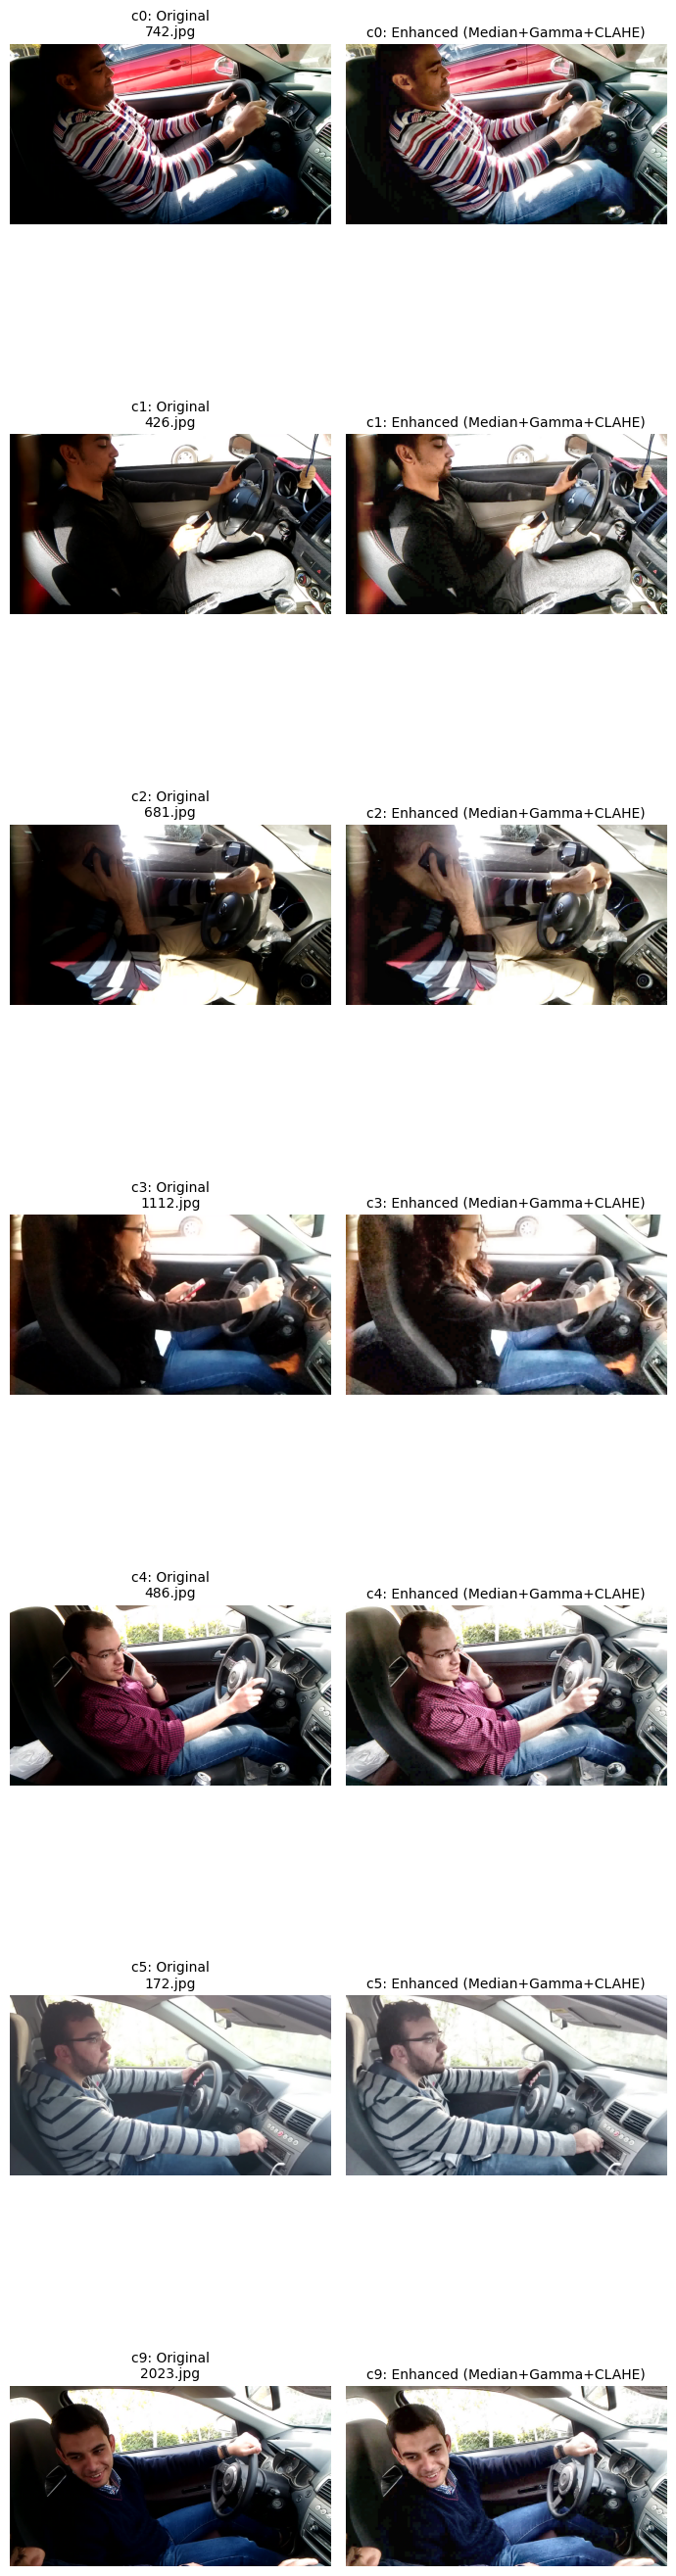

In [ ]:
import matplotlib.pyplot as plt
import random
import os
import cv2
import glob
""" Generates a side-by-side visual validation grid to verify the
 structural integrity of the preprocessing pipeline across all active classes."""

RAW_ROOT = "/content/ai_distracted2"
ENH_ROOT = "/content/ai_distracted_enhanced2"
split = "train"

classes = sorted(['c0','c1','c2','c3','c4','c5','c9'])
plt.figure(figsize=(7,40))

print(f"Visualizing comparison for split: {split}")

for i, cls in enumerate(classes):
    src_cls_path = os.path.join(RAW_ROOT , split , cls)

    images = []
    for ext in ("*.jpg","*.jpeg","*.png"):
        images.extend(glob.glob(os.path.join(src_cls_path, ext)))

    if not images:
        print(f"No images found for class {cls}")
        continue

    img_path_raw = random.choice(images)
    filename = os.path.basename(img_path_raw)
    img_path_enh = os.path.join(ENH_ROOT , split , cls, filename)
    img_raw = cv2.imread(img_path_raw)
    img_enh = cv2.imread(img_path_enh)

    if img_raw is not None:
        img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
    if img_enh is not None:
        img_enh = cv2.cvtColor(img_enh, cv2.COLOR_BGR2RGB)

    plt.subplot(10, 2, i*2 + 1)
    if img_raw is not None:
        plt.imshow(img_raw)
        plt.title(f"{cls}: Original\n{filename}", fontsize=10)
    else:
        plt.text(0.5, 0.5, 'Image Not Found', ha='center')
    plt.axis('off')

    plt.subplot(10, 2, i*2 + 2)
    if img_enh is not None:
        plt.imshow(img_enh)
        plt.title(f"{cls}: Enhanced (Median+Gamma+CLAHE)", fontsize=10)
    else:
        plt.text(0.5, 0.5, 'Enhanced File Not Found', ha='center')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import random
import os
import shutil
import glob
"""
Partitions the augmented training data into a train/validation split
to monitor YOLOv8-nano generalization and prevent overfitting.
"""
random.seed(42)

TRAIN_DIR = os.path.join(ENH_ROOT, "train")
VAL_DIR   = os.path.join(ENH_ROOT, "val")

if os.path.exists(VAL_DIR):
    shutil.rmtree(VAL_DIR)
os.makedirs(VAL_DIR, exist_ok=True)

VAL_RATIO = 0.2
classes = sorted(os.listdir(TRAIN_DIR))

for cls in classes:
    cls_train = os.path.join(TRAIN_DIR, cls)
    cls_val   = os.path.join(VAL_DIR, cls)
    os.makedirs(cls_val, exist_ok=True)

    images = []
    for ext in ("*.jpg","*.jpeg","*.png"):
        images += glob.glob(os.path.join(cls_train,ext))

    random.shuffle(images)
    n_val = int(len(images)*VAL_RATIO)

    for img in images[:n_val]:
        shutil.move(img , os.path.join(cls_val , os.path.basename(img)))

print(f"[INFO] Dataset partitioned successfully. split ratio: {VAL_RATIO}")

[INFO] Dataset partitioned successfully. split ratio: 0.2


In [ ]:
import shutil
from ultralytics import YOLO
import os
""" Executes the YOLOv8-nano training pipeline.
Implements heavy HSV color shifting and spatial augmentations to
prevent overfitting during the restricted 15-epoch run. """

dataset_path = os.path.abspath(ENH_ROOT)

model = YOLO("yolov8n-cls.pt")

model.train(
    data=dataset_path,
    epochs=15,
    imgsz=224,
    batch=32,

    degrees=15,
    translate=0.15,
    scale=0.4,
    fliplr=0.5,
    hsv_h=0.02,
    hsv_s=0.4,
    hsv_v=0.4,

    project="driver_radar",
    name="v2_enhanced2_clean_ep15"
)

print("[INFO] YOLOv8n training sequence completed successfully.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ai_distracted_enhanced2, degrees=15, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.4, hsv_v=0.4, 

[INFO] Loading model weights from: /content/runs/classify/driver_radar/v2_enhanced2_clean_ep15/weights/best.pt
[INFERENCE] Target: c9 | Prediction: c9 | Confidence: 99.9%


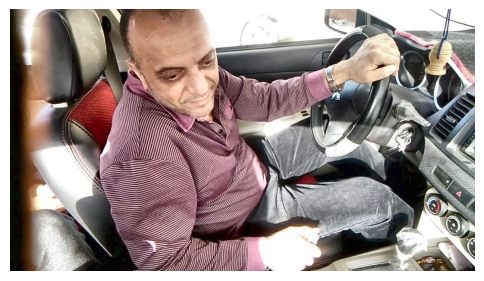

In [ ]:
from ultralytics import YOLO
import os, glob, random
import cv2
import matplotlib.pyplot as plt
""" Loads fine-tuned weights and executes inference on a randomized validation
 sample to verify confidence scoring. """

ENH_ROOT = "/content/ai_distracted_enhanced2"

BEST_WEIGHTS_PATH = "/content/runs/classify/driver_radar/v2_enhanced2_clean_ep15/weights/best.pt"
print(f"[INFO] Loading model weights from: {BEST_WEIGHTS_PATH}")
model = YOLO(BEST_WEIGHTS_PATH)


test_root = os.path.join(ENH_ROOT , "test")
all_imgs = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    all_imgs += glob.glob(os.path.join(test_root , "**" , ext), recursive=True)

assert len(all_imgs) > 0, "No test images found!"


img_path = random.choice(all_imgs)

true_class = os.path.basename(os.path.dirname(img_path))

res = model.predict(source=img_path,imgsz=224,verbose=False)[0]

pred_idx = int(res.probs.top1)
pred_conf = float(res.probs.top1conf)
pred_class = res.names[pred_idx]

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.axis("off")
print(f"[INFERENCE] Target: {true_class} | Prediction: {pred_class} | Confidence: {pred_conf*100:.1f}%")
plt.show()

Loading model from: /content/runs/classify/driver_radar/v2_enhanced2_clean_ep15/weights/best.pt
[INFERENCE] File: /content/image_test.png | Prediction: Talking on the Phone (100.0%)


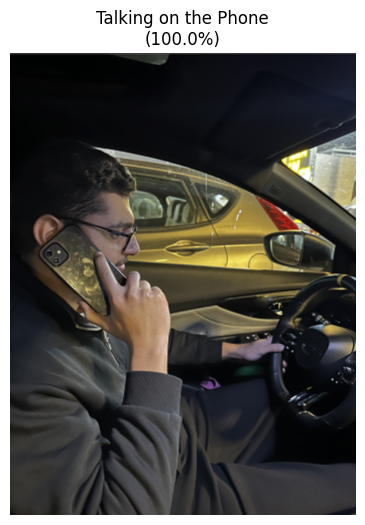

In [ ]:
from ultralytics import YOLO
import os
import cv2
import matplotlib.pyplot as plt
"""
Loads the fine-tuned YOLOv8-nano weights and executes a single-image
inference test, mapping the raw class output to a human-readable telemetry log.
"""

CLASS_MAP = {
    "c0": "Normal Driving",
    "c1": "Texting on the Phone (Hand)",
    "c2": "Talking on the Phone",
    "c3": "Texting on the Phone",
    "c4": "Talking on the Phone",
    "c5": "Playing with the Carscreen",
    "c9": "Distracted from the Road"
}

BEST_WEIGHTS_PATH = "/content/runs/classify/driver_radar/v2_enhanced2_clean_ep15/weights/best.pt"

print("Loading model from:", BEST_WEIGHTS_PATH)
try:
    model = YOLO(BEST_WEIGHTS_PATH)
except Exception as e:
    print(f"Error loading model: {e}")
    model = None

img_path = "/content/image_test.png"

if model and os.path.exists(img_path):
    res = model.predict(source=img_path , imgsz=224 , verbose=False)[0]

    pred_idx  = int(res.probs.top1)
    pred_conf = float(res.probs.top1conf)

    raw_name = res.names[pred_idx]


    readable_name = CLASS_MAP.get(raw_name, raw_name)

    print(f"[INFERENCE] File: {img_path} | Prediction: {readable_name} ({pred_conf*100:.1f}%)")

    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6,6))
        plt.imshow(img)
        plt.axis("off")

        plt.title(f"{readable_name}\n({pred_conf*100:.1f}%)")
        plt.show()
    else:
        print("[ERROR] Failed to decode image file. Verify file format and integrity.")

elif not model:
    print("[ERROR] Inference aborted: YOLO model weights failed to initialize.")
else:
    print(f"[ERROR] Test path resolution failed. Target not found: {img_path}")